## Libraries

In [ ]:
import pandas as pd
import plotly.express as px
from scipy import stats
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# ML Classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Optional: data splitting if not already done
from sklearn.model_selection import train_test_split


# EDA (Exploratory Data Analysis)

In [ ]:
file_path = '/content/drive/MyDrive/ML3/Copy of risk_models_training_uae.xlsx'

# Load only the required sheet
df = pd.read_excel(file_path, sheet_name='4_Country_of_origin')

df.head()

,declaration_id,declaration_date,importer_id,exporter_id,hs_code,declared_value,currency,origin_country,transport_mode,route,container_count,packaging_type,inspection_history_count,previous_overall_risk_score,certificate_of_origin,country_risk_score,origin_verification_failures,origin_flag
0,DCL00001,2024-03-29,IMP357,EXP199,29211920,46561.43,CNY,DE,road,DEAE,5,box,3,0.34,NaN,0.06,NaN,0
1,DCL00002,2025-06-05,IMP134,EXP459,85171200,23743.07,USD,CN,road,SGAE,2,loose,0,0.51,NaN,0.57,NaN,0
2,DCL00003,2024-01-03,IMP446,EXP340,71131990,44993.75,SAR,SG,road,INAE,4,box,5,0.27,NaN,0.65,NaN,0
3,DCL00004,2025-04-11,IMP093,EXP092,10061001,33719.88,SAR,SG,sea,USAE,3,bag,3,0.44,NaN,0.90,NaN,0
4,DCL00005,2024-03-15,IMP399,EXP338,93049099,39873.53,EUR,CN,sea,INAE,4,loose,5,0.53,NaN,0.42,NaN,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   declaration_id                10000 non-null  object 
 1   declaration_date              10000 non-null  object 
 2   importer_id                   10000 non-null  object 
 3   exporter_id                   10000 non-null  object 
 4   hs_code                       10000 non-null  int64  
 5   declared_value                10000 non-null  float64
 6   currency                      10000 non-null  object 
 7   origin_country                10000 non-null  object 
 8   transport_mode                10000 non-null  object 
 9   route                         10000 non-null  object 
 10  container_count               10000 non-null  int64  
 11  packaging_type                10000 non-null  object 
 12  inspection_history_count      10000 non-null  int64  
 13  pr

In [ ]:
df.describe()

,hs_code,declared_value,container_count,inspection_history_count,previous_overall_risk_score,certificate_of_origin,country_risk_score,origin_verification_failures,origin_flag
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,0.0,10000.000000,0.0,10000.000000
mean,3.667884e+07,25219.387671,3.017100,2.484100,0.497543,NaN,0.500253,NaN,0.505800
std,3.451451e+07,14393.592117,1.417183,1.712904,0.290144,NaN,0.288003,NaN,0.499991
min,1.012100e+06,110.060000,1.000000,0.000000,0.000000,NaN,0.000000,NaN,0.000000
25%,1.006100e+07,12824.965000,2.000000,1.000000,0.240000,NaN,0.250000,NaN,0.000000
50%,2.921192e+07,25348.005000,3.000000,2.000000,0.500000,NaN,0.500000,NaN,1.000000
75%,7.113199e+07,37612.235000,4.000000,4.000000,0.750000,NaN,0.750000,NaN,1.000000
max,9.304910e+07,49983.090000,5.000000,5.000000,1.000000,NaN,1.000000,NaN,1.000000


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
hs_code,10000.0,3.667884e+07,3.451451e+07,1012100.00,1.006100e+07,2.921192e+07,7.113199e+07,93049099.00
declared_value,10000.0,2.521939e+04,1.439359e+04,110.06,1.282497e+04,2.534800e+04,3.761224e+04,49983.09
container_count,10000.0,3.017100e+00,1.417183e+00,1.00,2.000000e+00,3.000000e+00,4.000000e+00,5.00
inspection_history_count,10000.0,2.484100e+00,1.712904e+00,0.00,1.000000e+00,2.000000e+00,4.000000e+00,5.00
previous_overall_risk_score,10000.0,4.975430e-01,2.901439e-01,0.00,2.400000e-01,5.000000e-01,7.500000e-01,1.00
certificate_of_origin,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_risk_score,10000.0,5.002530e-01,2.880028e-01,0.00,2.500000e-01,5.000000e-01,7.500000e-01,1.00
origin_verification_failures,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
origin_flag,10000.0,5.058000e-01,4.999914e-01,0.00,0.000000e+00,1.000000e+00,1.000000e+00,1.00


In [ ]:
df.head()

,declaration_id,declaration_date,importer_id,exporter_id,hs_code,declared_value,currency,origin_country,transport_mode,route,container_count,packaging_type,inspection_history_count,previous_overall_risk_score,certificate_of_origin,country_risk_score,origin_verification_failures,origin_flag
0,DCL00001,2024-03-29,IMP357,EXP199,29211920,46561.43,CNY,DE,road,DEAE,5,box,3,0.34,NaN,0.06,NaN,0
1,DCL00002,2025-06-05,IMP134,EXP459,85171200,23743.07,USD,CN,road,SGAE,2,loose,0,0.51,NaN,0.57,NaN,0
2,DCL00003,2024-01-03,IMP446,EXP340,71131990,44993.75,SAR,SG,road,INAE,4,box,5,0.27,NaN,0.65,NaN,0
3,DCL00004,2025-04-11,IMP093,EXP092,10061001,33719.88,SAR,SG,sea,USAE,3,bag,3,0.44,NaN,0.90,NaN,0
4,DCL00005,2024-03-15,IMP399,EXP338,93049099,39873.53,EUR,CN,sea,INAE,4,loose,5,0.53,NaN,0.42,NaN,0


In [ ]:
unique_features = df.drop(columns=["declaration_date","declaration_id","declared_value"]).columns.tolist()
print(unique_features)

['importer_id', 'exporter_id', 'hs_code', 'currency', 'origin_country', 'transport_mode', 'route', 'container_count', 'packaging_type', 'inspection_history_count', 'previous_overall_risk_score', 'certificate_of_origin', 'country_risk_score', 'origin_verification_failures', 'origin_flag']


In [ ]:
df['origin_flag'].value_counts()

,count
origin_flag,
1,5058
0,4942


In [ ]:
for column in unique_features:
  print(column,'---',df[column].unique())
  print('---------------------------')

importer_id --- ['IMP357' 'IMP134' 'IMP446' 'IMP093' 'IMP399' 'IMP268' 'IMP394' 'IMP182'
 'IMP091' 'IMP066' 'IMP497' 'IMP248' 'IMP151' 'IMP343' 'IMP203' 'IMP236'
 'IMP259' 'IMP356' 'IMP114' 'IMP074' 'IMP160' 'IMP138' 'IMP202' 'IMP027'
 'IMP081' 'IMP198' 'IMP329' 'IMP368' 'IMP041' 'IMP316' 'IMP421' 'IMP092'
 'IMP023' 'IMP291' 'IMP327' 'IMP230' 'IMP332' 'IMP300' 'IMP088' 'IMP470'
 'IMP190' 'IMP188' 'IMP242' 'IMP122' 'IMP349' 'IMP181' 'IMP398' 'IMP452'
 'IMP261' 'IMP238' 'IMP039' 'IMP350' 'IMP469' 'IMP054' 'IMP436' 'IMP244'
 'IMP418' 'IMP191' 'IMP306' 'IMP260' 'IMP481' 'IMP173' 'IMP438' 'IMP379'
 'IMP472' 'IMP068' 'IMP030' 'IMP196' 'IMP407' 'IMP480' 'IMP077' 'IMP206'
 'IMP305' 'IMP229' 'IMP002' 'IMP176' 'IMP393' 'IMP437' 'IMP442' 'IMP008'
 'IMP296' 'IMP140' 'IMP078' 'IMP361' 'IMP253' 'IMP085' 'IMP353' 'IMP408'
 'IMP493' 'IMP089' 'IMP416' 'IMP212' 'IMP424' 'IMP218' 'IMP288' 'IMP222'
 'IMP309' 'IMP170' 'IMP017' 'IMP280' 'IMP378' 'IMP317' 'IMP430' 'IMP330'
 'IMP477' 'IMP155' 'IMP072' 'IMP389

In [ ]:
for column in unique_features:
    print(column, '---', df[column].nunique())
    print('---------------------------')


importer_id --- 500
---------------------------
exporter_id --- 500
---------------------------
hs_code --- 9
---------------------------
currency --- 6
---------------------------
origin_country --- 6
---------------------------
transport_mode --- 3
---------------------------
route --- 6
---------------------------
container_count --- 5
---------------------------
packaging_type --- 4
---------------------------
inspection_history_count --- 6
---------------------------
previous_overall_risk_score --- 101
---------------------------
certificate_of_origin --- 0
---------------------------
country_risk_score --- 101
---------------------------
origin_verification_failures --- 0
---------------------------
origin_flag --- 2
---------------------------


In [ ]:
for column in df.columns:
    print(column, '---', df[column].nunique())
    print('---------------------------')


declaration_id --- 10000
---------------------------
declaration_date --- 546
---------------------------
importer_id --- 500
---------------------------
exporter_id --- 500
---------------------------
hs_code --- 9
---------------------------
declared_value --- 9985
---------------------------
currency --- 6
---------------------------
origin_country --- 6
---------------------------
transport_mode --- 3
---------------------------
route --- 6
---------------------------
container_count --- 5
---------------------------
packaging_type --- 4
---------------------------
inspection_history_count --- 6
---------------------------
previous_overall_risk_score --- 101
---------------------------
certificate_of_origin --- 0
---------------------------
country_risk_score --- 101
---------------------------
origin_verification_failures --- 0
---------------------------
origin_flag --- 2
---------------------------


In [ ]:
# make sure it's datetime
df['declaration_date'] = pd.to_datetime(df['declaration_date'])

# extract year
unique_years = df['declaration_date'].dt.year.unique()

print(unique_years)

[2024 2025]


## Correlation Testing

In [ ]:
# To test only numerical features
numerical_df = df.select_dtypes(['float64','int64'])
numerical_df.corr()

,hs_code,declared_value,container_count,inspection_history_count,previous_overall_risk_score,certificate_of_origin,country_risk_score,origin_verification_failures,origin_flag
hs_code,1.000000,-0.002375,-0.000266,-0.006938,-0.006267,NaN,-0.001733,NaN,0.014690
declared_value,-0.002375,1.000000,0.009080,-0.001861,0.015753,NaN,0.013497,NaN,0.007065
container_count,-0.000266,0.009080,1.000000,-0.008313,-0.005314,NaN,0.001685,NaN,-0.003175
inspection_history_count,-0.006938,-0.001861,-0.008313,1.000000,-0.003796,NaN,0.016505,NaN,0.005771
previous_overall_risk_score,-0.006267,0.015753,-0.005314,-0.003796,1.000000,NaN,-0.015239,NaN,-0.015389
certificate_of_origin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_risk_score,-0.001733,0.013497,0.001685,0.016505,-0.015239,NaN,1.000000,NaN,-0.016731
origin_verification_failures,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
origin_flag,0.014690,0.007065,-0.003175,0.005771,-0.015389,NaN,-0.016731,NaN,1.000000


In [ ]:
correlation_matrix = numerical_df.corr()
fig = px.imshow(correlation_matrix, color_continuous_scale='Cividis',
                title="Correlation Matrix")
fig.show()

## Hypothesis Testing

Hypothesis testing / Statistical analysis

Continuous - Central Limit Theorem, 1-Tailed Test (one-sample t-test)

Continuous vs. Continuous - Correlation, 2-Tailed Test (two-sample t-test)

Continuous vs. Categorical - ANOVA (Analysis of Variance)

Categorical vs. Categorical - Chi-Square Test

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

def hypothesisTesting(df, continuous_columns = [], category_columns = [], sampling_rate = 0.20, sampling_frac=0.05, alpha=0.05):
    oneContinesColumn_result = {}
    hypothesis_df = pd.DataFrame("", index=df.columns, columns=df.columns)

    # Central Limit Theorem
    if continuous_columns:
        samplesize = int(sampling_rate * len(df[continuous_columns[0]]))
        for column in continuous_columns:
            population = df[column].dropna().values
            if len(population) < 2:
                continue
            population_mean = population.mean()
            sample_mean = []
            for i in range(40):
                sample = np.random.choice(population, samplesize)
                sample_mean.append(sample.mean())
            oneContinesColumn_result[column] = {
                "Population Mean": population_mean,
                "Sample Means": np.mean(sample_mean)
            }

    # 1-Tailed Test
    if continuous_columns:
        samplesize = int(sampling_rate * len(df[continuous_columns[0]]))
        for column in continuous_columns:
            H0_accepted = 0
            H0_rejected = 0
            for i in range(samplesize):
                col_numeric = df[column].dropna()
                if len(col_numeric) < 2:
                    continue
                sample = col_numeric.sample(frac=sampling_frac)
                if len(sample) > 1:   # ✅ skip too-small samples
                    t_test, p_value = stats.ttest_1samp(sample, col_numeric.mean())
                    if p_value > alpha:
                        H0_accepted += 1
                    else:
                        H0_rejected += 1

            if column not in oneContinesColumn_result:
                oneContinesColumn_result[column] = {}

            if H0_accepted > H0_rejected:
                oneContinesColumn_result[column].update({
                    "H0_accepted": H0_accepted,
                    "H0_rejected": H0_rejected,
                    "Conclusion": "H0 is accepted, no significant effect"
                })
            else:
                oneContinesColumn_result[column].update({
                    "H0_accepted": H0_accepted,
                    "H0_rejected": H0_rejected,
                    "Conclusion": "H0 is rejected, significant effect exists"
                })

    # 2-Tailed Test
    for i in range(len(continuous_columns) - 1):
        column_1 = continuous_columns[i]
        for column_2 in continuous_columns[i + 1:]:
            H0_accepted = 0
            H0_rejected = 0
            for _ in range(20):
                sample1 = df[column_1].dropna().sample(frac=sampling_frac)
                sample2 = df[column_2].dropna().sample(frac=sampling_frac)

                if len(sample1) > 1 and len(sample2) > 1:  # ✅ guard
                    t_test, p_value = stats.ttest_ind(sample1, sample2)
                    if p_value > alpha:
                        H0_accepted += 1
                    else:
                        H0_rejected += 1

            if H0_accepted > H0_rejected:
                hypothesis_df.loc[column_1, column_2] = "H0 is accepted"
                hypothesis_df.loc[column_2, column_1] = "H0 is accepted"
            else:
                hypothesis_df.loc[column_1, column_2] = "H0 is rejected"
                hypothesis_df.loc[column_2, column_1] = "H0 is rejected"

    # Chi-Square Test
    if category_columns:
        for i in range(len(category_columns) - 1):
            column_1 = category_columns[i]
            for column_2 in category_columns[i + 1:]:
                data = pd.crosstab(df[column_1], df[column_2])
                observed_values = data.values
                if observed_values.size > 0:   # ✅ avoid empty crosstabs
                    chi2_stat, p_value, _, _ = stats.chi2_contingency(observed_values)
                    if p_value > alpha:
                        hypothesis_df.loc[column_1, column_2] = "H0 is accepted"
                        hypothesis_df.loc[column_2, column_1] = "H0 is accepted"
                    else:
                        hypothesis_df.loc[column_1, column_2] = "H0 is rejected"
                        hypothesis_df.loc[column_2, column_1] = "H0 is rejected"

    # ANOVA
    if continuous_columns and category_columns:
        for category_column in category_columns:
            for continuous_column in continuous_columns:
                groups = df[category_column].dropna().unique()
                data = [df.loc[df[category_column] == g, continuous_column].dropna()
                        for g in groups if len(df.loc[df[category_column] == g, continuous_column].dropna()) > 1]

                if len(data) > 1:   # ✅ at least 2 groups with valid samples
                    f_value, p_value = stats.f_oneway(*data)
                    if p_value > alpha:
                        hypothesis_df.loc[category_column, continuous_column] = "H0 is accepted"
                        hypothesis_df.loc[continuous_column, category_column] = "H0 is accepted"
                    else:
                        hypothesis_df.loc[category_column, continuous_column] = "H0 is rejected"
                        hypothesis_df.loc[continuous_column, category_column] = "H0 is rejected"

    return oneContinesColumn_result, hypothesis_df


In [ ]:
continuous_columns = ["declaration_date","declared_value"]
category_columns = ['importer_id', 'exporter_id', 'hs_code', 'currency', 'origin_country', 'transport_mode', 'route', 'container_count', 'packaging_type', 'inspection_history_count', 'previous_overall_risk_score', 'country_risk_score', 'origin_flag']

In [ ]:
df[continuous_columns] = df[continuous_columns].apply(pd.to_numeric, errors='coerce')

In [ ]:
ContinesColumn_result, comperativeColumn_result = hypothesisTesting(
    df,
    continuous_columns,
    category_columns
)

In [ ]:
ContinesColumn_result_df = pd.DataFrame(ContinesColumn_result)
ContinesColumn_result_df

,declaration_date,declared_value
Population Mean,1727270861759999744.0,25219.387671
Sample Means,1727279071920000000.0,25230.660867
H0_accepted,1905,1920
H0_rejected,95,80
Conclusion,"H0 is accepted, no significant effect","H0 is accepted, no significant effect"


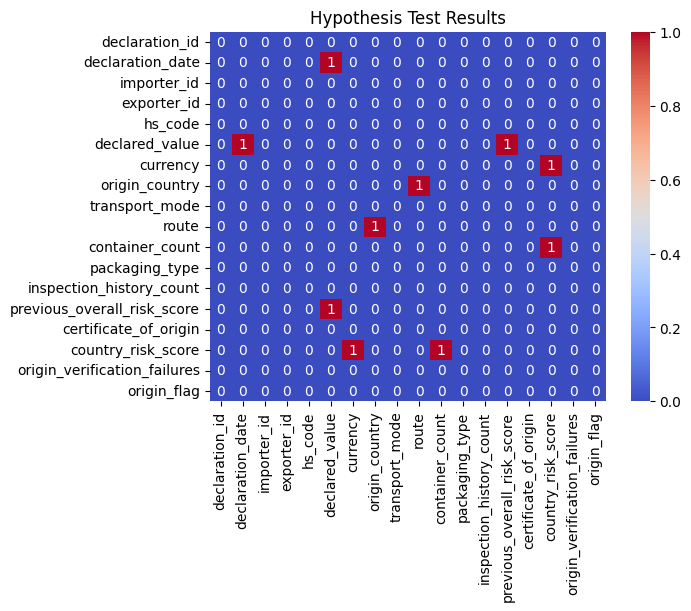

In [ ]:
# Create a heatmap
sns.heatmap(comperativeColumn_result == 'H0 is rejected', annot=True, cmap='coolwarm')
plt.title('Hypothesis Test Results')
plt.show()

In [ ]:
# Assuming comperativeColumn_result is your dictionary for categorical tests
comperativeColumn_result_df = pd.DataFrame(comperativeColumn_result)

# Display
comperativeColumn_result_df


,declaration_id,declaration_date,importer_id,exporter_id,hs_code,declared_value,currency,origin_country,transport_mode,route,container_count,packaging_type,inspection_history_count,previous_overall_risk_score,certificate_of_origin,country_risk_score,origin_verification_failures,origin_flag
declaration_id,,,,,,,,,,,,,,,,,,
declaration_date,,,H0 is accepted,H0 is accepted,H0 is accepted,H0 is rejected,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,,H0 is accepted,,H0 is accepted
importer_id,,H0 is accepted,,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,,H0 is accepted,,H0 is accepted
exporter_id,,H0 is accepted,H0 is accepted,,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,,H0 is accepted,,H0 is accepted
hs_code,,H0 is accepted,H0 is accepted,H0 is accepted,,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,,H0 is accepted,,H0 is accepted
declared_value,,H0 is rejected,H0 is accepted,H0 is accepted,H0 is accepted,,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is rejected,,H0 is accepted,,H0 is accepted
currency,,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,,H0 is rejected,,H0 is accepted
origin_country,,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,,H0 is accepted,H0 is rejected,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,,H0 is accepted,,H0 is accepted
transport_mode,,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,,H0 is accepted,,H0 is accepted
route,,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,H0 is rejected,H0 is accepted,,H0 is accepted,H0 is accepted,H0 is accepted,H0 is accepted,,H0 is accepted,,H0 is accepted


## Data visualization

Univariate and Bivariate Analysis

In [ ]:
file_path = '/content/drive/MyDrive/ML3/Copy of risk_models_training_uae.xlsx'

# Load only the required sheet
df = pd.read_excel(file_path, sheet_name='4_Country_of_origin')

df.head()

,declaration_id,declaration_date,importer_id,exporter_id,hs_code,declared_value,currency,origin_country,transport_mode,route,container_count,packaging_type,inspection_history_count,previous_overall_risk_score,certificate_of_origin,country_risk_score,origin_verification_failures,origin_flag
0,DCL00001,2024-03-29,IMP357,EXP199,29211920,46561.43,CNY,DE,road,DEAE,5,box,3,0.34,NaN,0.06,NaN,0
1,DCL00002,2025-06-05,IMP134,EXP459,85171200,23743.07,USD,CN,road,SGAE,2,loose,0,0.51,NaN,0.57,NaN,0
2,DCL00003,2024-01-03,IMP446,EXP340,71131990,44993.75,SAR,SG,road,INAE,4,box,5,0.27,NaN,0.65,NaN,0
3,DCL00004,2025-04-11,IMP093,EXP092,10061001,33719.88,SAR,SG,sea,USAE,3,bag,3,0.44,NaN,0.90,NaN,0
4,DCL00005,2024-03-15,IMP399,EXP338,93049099,39873.53,EUR,CN,sea,INAE,4,loose,5,0.53,NaN,0.42,NaN,0


In [ ]:
continuous_columns = ["declaration_date","declaration_id","declared_value"]
category_columns = ['importer_id', 'exporter_id', 'hs_code', 'currency', 'origin_country', 'transport_mode', 'route', 'container_count', 'packaging_type', 'inspection_history_count', 'previous_overall_risk_score', 'country_risk_score', 'origin_flag']

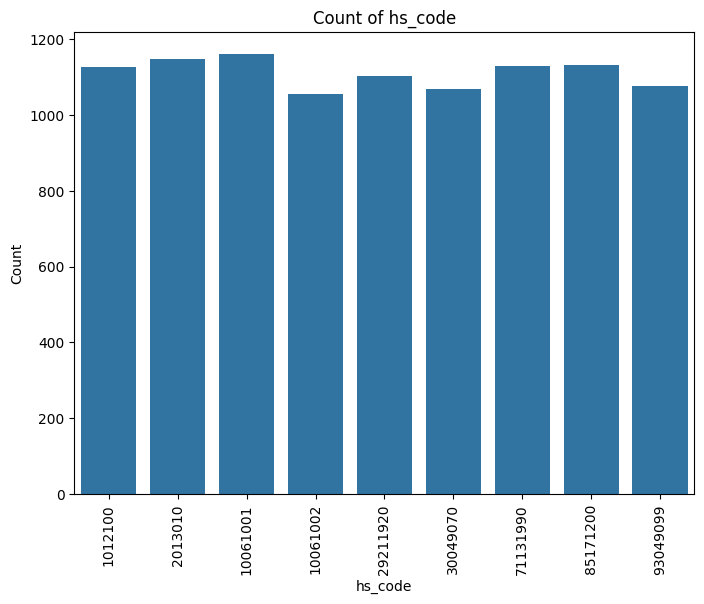

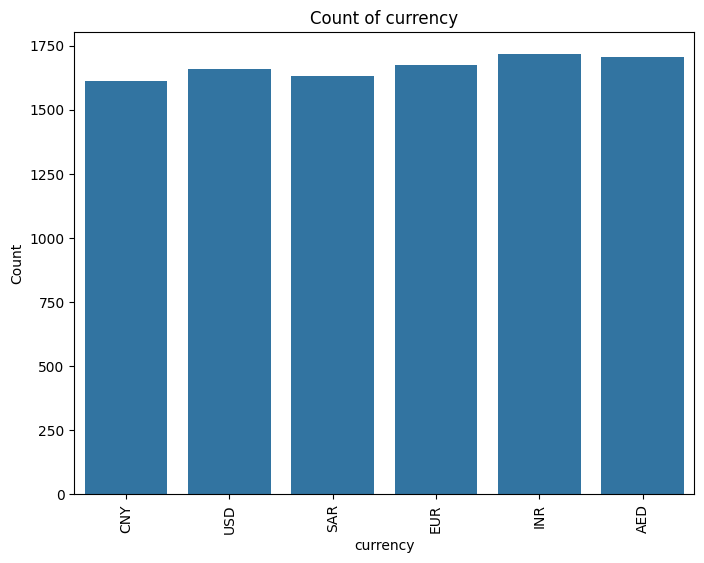

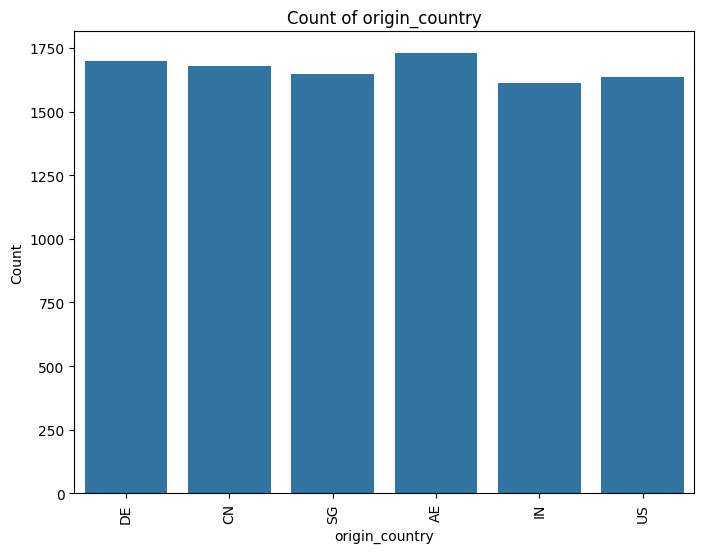

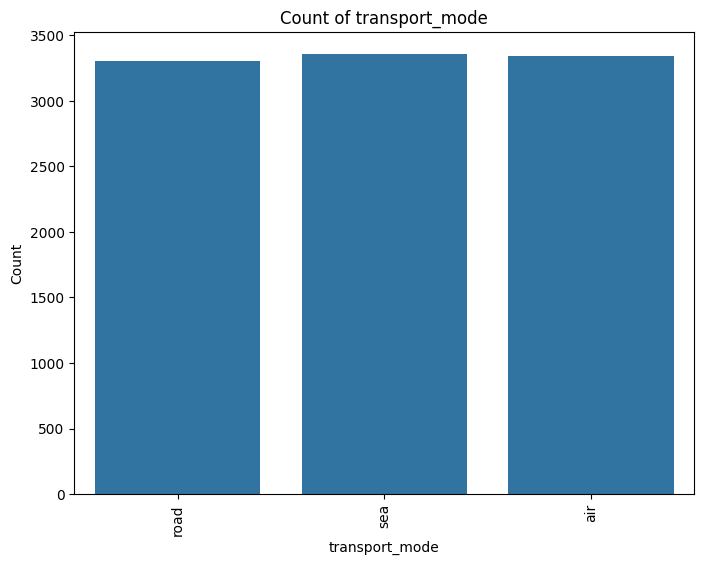

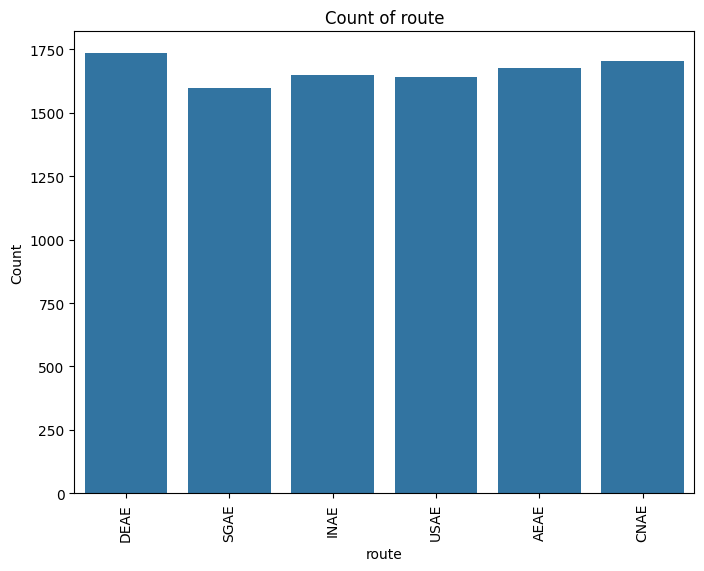

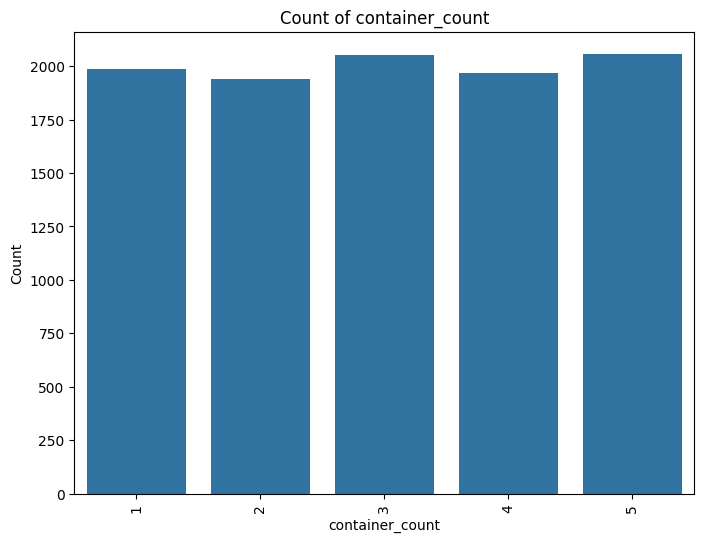

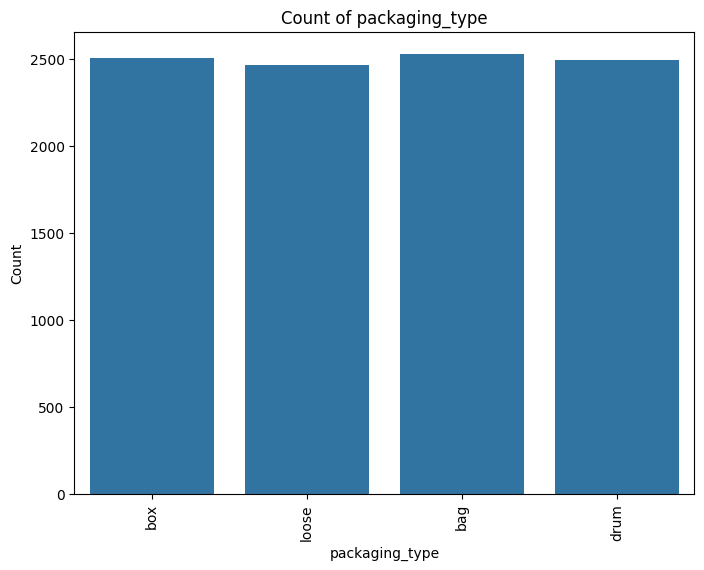

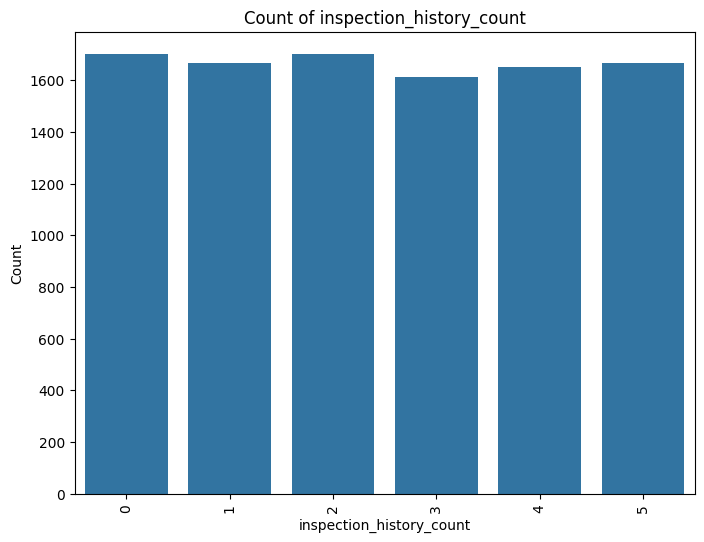

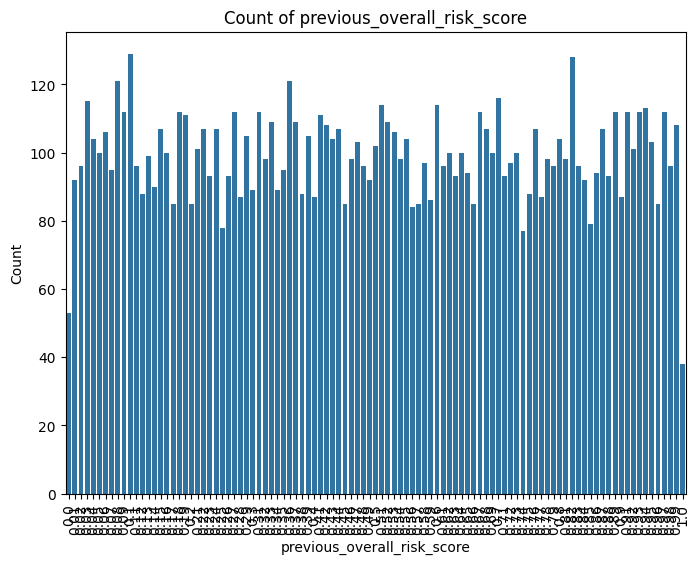

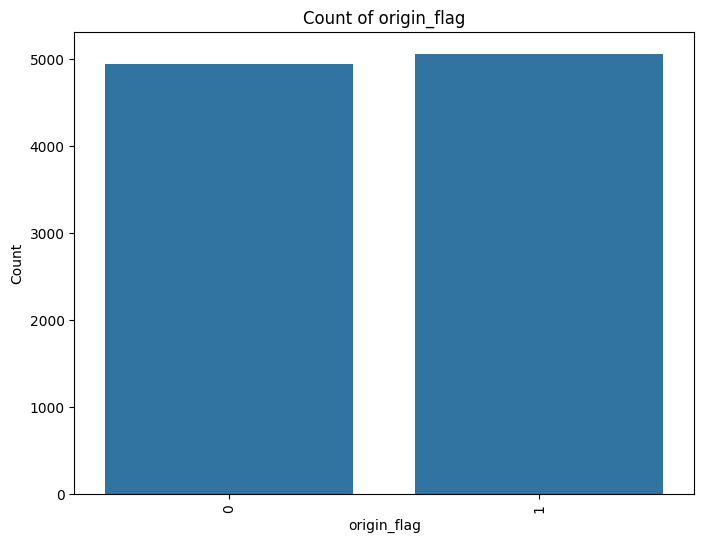

In [ ]:
features = ['hs_code', 'currency', 'origin_country', 'transport_mode', 'route', 'container_count', 'packaging_type', 'inspection_history_count', 'previous_overall_risk_score', 'origin_flag']
# Loop through each feature and create a count plot
for feature in features:
    plt.figure(figsize=(8, 6))
    sns.countplot(x=feature, data=df)
    plt.title(f'Count of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.show()

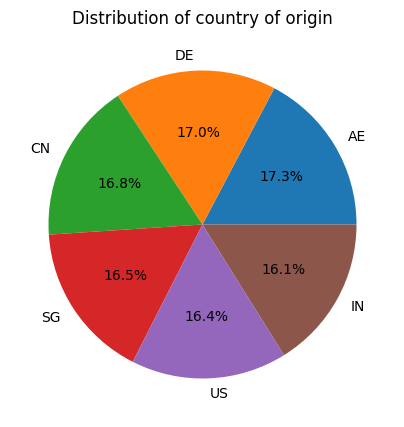

In [ ]:
# Pie chart
plt.figure(figsize=(5, 5))
df['origin_country'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of country of origin')
plt.ylabel('')
plt.show()

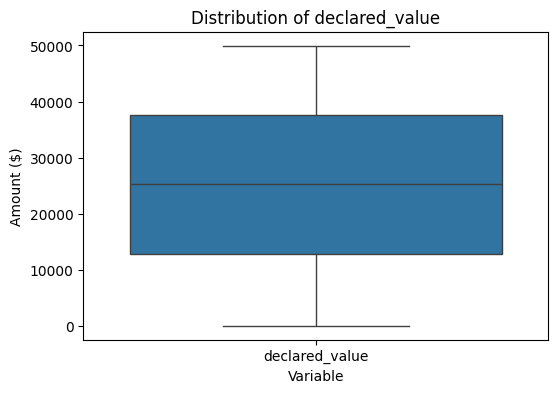

In [ ]:
# Box plot
plt.figure(figsize=(6, 4))
sns.boxplot(data=df[["declared_value"]])
plt.title('Distribution of declared_value')
plt.ylabel('Amount ($)')
plt.xlabel('Variable')
plt.show()

In [ ]:
df.head()

,declaration_id,declaration_date,importer_id,exporter_id,hs_code,declared_value,currency,origin_country,transport_mode,route,container_count,packaging_type,inspection_history_count,previous_overall_risk_score,certificate_of_origin,country_risk_score,origin_verification_failures,origin_flag
0,DCL00001,2024-03-29,IMP357,EXP199,29211920,46561.43,CNY,DE,road,DEAE,5,box,3,0.34,NaN,0.06,NaN,0
1,DCL00002,2025-06-05,IMP134,EXP459,85171200,23743.07,USD,CN,road,SGAE,2,loose,0,0.51,NaN,0.57,NaN,0
2,DCL00003,2024-01-03,IMP446,EXP340,71131990,44993.75,SAR,SG,road,INAE,4,box,5,0.27,NaN,0.65,NaN,0
3,DCL00004,2025-04-11,IMP093,EXP092,10061001,33719.88,SAR,SG,sea,USAE,3,bag,3,0.44,NaN,0.90,NaN,0
4,DCL00005,2024-03-15,IMP399,EXP338,93049099,39873.53,EUR,CN,sea,INAE,4,loose,5,0.53,NaN,0.42,NaN,0


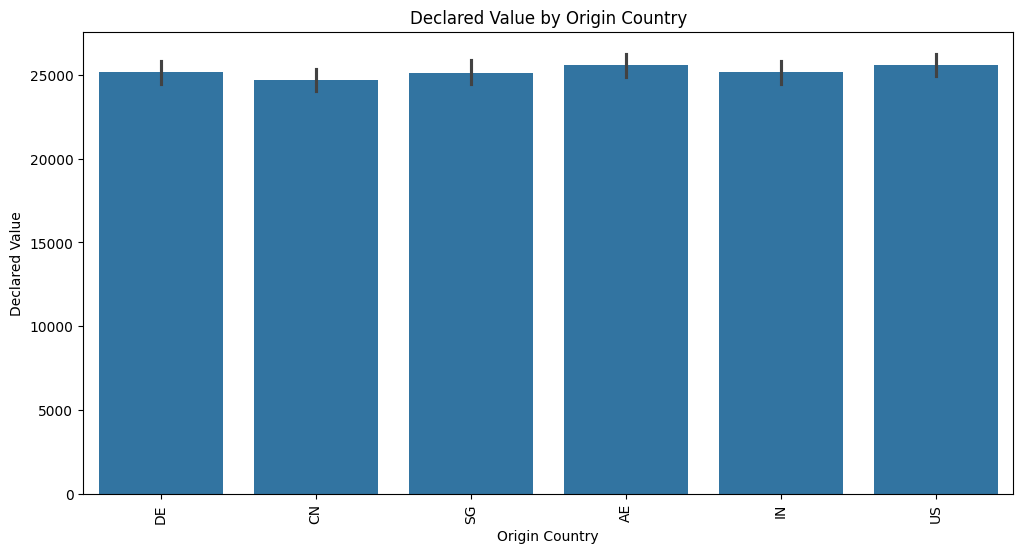

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x="origin_country", y="declared_value", data=df)
plt.xticks(rotation=90)   # rotate x labels for readability
plt.title("Declared Value by Origin Country")
plt.xlabel("Origin Country")
plt.ylabel("Declared Value")
plt.show()

In [ ]:
import plotly.express as px

# Aggregate so each country has one bar
agg_df = df.groupby("origin_country", as_index=False)["declared_value"].sum()

# Define your custom color palette
#custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
custom_colors = [
    "#4E79A7",  # Muted Blue
    "#F28E2B",  # Soft Orange
    "#E15759",  # Muted Red
    "#76B7B2",  # Teal
    "#59A14F",  # Muted Green
    "#EDC948"   # Warm Yellow
]

fig = px.bar(
    agg_df,
    x="origin_country",
    y="declared_value",
    text="declared_value",
    title="Total Declared Value by Origin Country",
    color="origin_country",
    color_discrete_sequence=custom_colors  # use your custom colors
)

# Make bars fully solid and improve layout
fig.update_traces(marker=dict(opacity=1))
fig.update_layout(
    xaxis_title="Origin Country",
    yaxis_title="Total Declared Value",
    xaxis_tickangle=-45,
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.show()


# Data Preprocessing

## Data Cleaning

In [ ]:
import pandas as pd
file_path = '/content/drive/MyDrive/ML3/Copy of risk_models_training_uae.xlsx'

# Load only the required sheet
df = pd.read_excel(file_path, sheet_name='4_Country_of_origin')

df.head()

,declaration_id,declaration_date,importer_id,exporter_id,hs_code,declared_value,currency,origin_country,transport_mode,route,container_count,packaging_type,inspection_history_count,previous_overall_risk_score,certificate_of_origin,country_risk_score,origin_verification_failures,origin_flag
0,DCL00001,2024-03-29,IMP357,EXP199,29211920,46561.43,CNY,DE,road,DEAE,5,box,3,0.34,NaN,0.06,NaN,0
1,DCL00002,2025-06-05,IMP134,EXP459,85171200,23743.07,USD,CN,road,SGAE,2,loose,0,0.51,NaN,0.57,NaN,0
2,DCL00003,2024-01-03,IMP446,EXP340,71131990,44993.75,SAR,SG,road,INAE,4,box,5,0.27,NaN,0.65,NaN,0
3,DCL00004,2025-04-11,IMP093,EXP092,10061001,33719.88,SAR,SG,sea,USAE,3,bag,3,0.44,NaN,0.90,NaN,0
4,DCL00005,2024-03-15,IMP399,EXP338,93049099,39873.53,EUR,CN,sea,INAE,4,loose,5,0.53,NaN,0.42,NaN,0


Both certificate_of_origin and origin_verification_failures columns contain only missing values (0 non-null counts). Since they don’t provide any information, we safely drop them from the dataset.

In [ ]:
df.drop(columns = ['certificate_of_origin','origin_verification_failures'], inplace=True)

declaration_id is just an identifier. Keeping it won’t help in analysis or modeling, since it doesn’t contribute to patterns or relationships in the data.

In [ ]:
df.drop(columns = ['declaration_id','declaration_date','currency'], inplace=True)

In [ ]:
df.head(2)

,importer_id,exporter_id,hs_code,declared_value,origin_country,transport_mode,route,container_count,packaging_type,inspection_history_count,previous_overall_risk_score,country_risk_score,origin_flag
0,IMP357,EXP199,29211920,46561.43,DE,road,DEAE,5,box,3,0.34,0.06,0
1,IMP134,EXP459,85171200,23743.07,CN,road,SGAE,2,loose,0,0.51,0.57,0


In [ ]:
unique_features = df.drop(columns=["declaration_date","declaration_id","declared_value"]).columns.tolist()
print(unique_features)

In [ ]:
for column in df.columns:
  print(column,'---',df[column].unique())
  print('---------------------------')

importer_id --- ['IMP357' 'IMP134' 'IMP446' 'IMP093' 'IMP399' 'IMP268' 'IMP394' 'IMP182'
 'IMP091' 'IMP066' 'IMP497' 'IMP248' 'IMP151' 'IMP343' 'IMP203' 'IMP236'
 'IMP259' 'IMP356' 'IMP114' 'IMP074' 'IMP160' 'IMP138' 'IMP202' 'IMP027'
 'IMP081' 'IMP198' 'IMP329' 'IMP368' 'IMP041' 'IMP316' 'IMP421' 'IMP092'
 'IMP023' 'IMP291' 'IMP327' 'IMP230' 'IMP332' 'IMP300' 'IMP088' 'IMP470'
 'IMP190' 'IMP188' 'IMP242' 'IMP122' 'IMP349' 'IMP181' 'IMP398' 'IMP452'
 'IMP261' 'IMP238' 'IMP039' 'IMP350' 'IMP469' 'IMP054' 'IMP436' 'IMP244'
 'IMP418' 'IMP191' 'IMP306' 'IMP260' 'IMP481' 'IMP173' 'IMP438' 'IMP379'
 'IMP472' 'IMP068' 'IMP030' 'IMP196' 'IMP407' 'IMP480' 'IMP077' 'IMP206'
 'IMP305' 'IMP229' 'IMP002' 'IMP176' 'IMP393' 'IMP437' 'IMP442' 'IMP008'
 'IMP296' 'IMP140' 'IMP078' 'IMP361' 'IMP253' 'IMP085' 'IMP353' 'IMP408'
 'IMP493' 'IMP089' 'IMP416' 'IMP212' 'IMP424' 'IMP218' 'IMP288' 'IMP222'
 'IMP309' 'IMP170' 'IMP017' 'IMP280' 'IMP378' 'IMP317' 'IMP430' 'IMP330'
 'IMP477' 'IMP155' 'IMP072' 'IMP389

# Feature engineering & Encoding

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils import resample
import joblib
# -------------------------------
# Load dataset
# -------------------------------
# df = pd.read_csv("path_to_dataset.csv")  # Replace with your path

# -------------------------------
# Oversample / increase dataset size
# -------------------------------
df_non_risky = df[df['origin_flag'] == 0]
df_risky = df[df['origin_flag'] == 1]

df_majority_oversampled = resample(df_non_risky, replace=True, n_samples=len(df_non_risky)*12, random_state=42)
df_minority_oversampled = resample(df_risky, replace=True, n_samples=len(df_risky)*4, random_state=42)

df_oversampled = pd.concat([df_majority_oversampled, df_minority_oversampled]).reset_index(drop=True)
print("Oversampled dataset shape:", df_oversampled.shape)
print(df_oversampled['origin_flag'].value_counts())

# -------------------------------
# Custom Frequency Encoder
# -------------------------------
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.freq_map = {}

    def fit(self, X, y=None):
        for col in X.columns:
            freq = X[col].value_counts()
            self.freq_map[col] = freq.to_dict()
        return self

    def transform(self, X):
        X_encoded = X.copy()
        for col in X.columns:
            X_encoded[col] = X[col].map(self.freq_map[col]).fillna(0)
        return X_encoded

# -------------------------------
# Columns definition
# -------------------------------
freq_cols = ["importer_id", "exporter_id",'previous_overall_risk_score','country_risk_score']
onehot_cols = ["origin_country", "transport_mode", "route", 'container_count','hs_code','packaging_type','inspection_history_count']
scale_cols = ["declared_value"]

# -------------------------------
# Column Transformer
# -------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("freq", FrequencyEncoder(), freq_cols),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), onehot_cols),
        ("scale", StandardScaler(), scale_cols),
    ]
)

# -------------------------------
# Pipeline
# -------------------------------
pipeline = Pipeline(steps=[("preprocessor", preprocessor)])

# -------------------------------
# Fit + Transform on oversampled dataset
# -------------------------------
X_encoded_values = pipeline.fit_transform(df_oversampled)

# -------------------------------
# Convert to DataFrame
# -------------------------------
ohe = pipeline.named_steps["preprocessor"].named_transformers_["onehot"]
ohe_features = ohe.get_feature_names_out(onehot_cols)

all_features = freq_cols + list(ohe_features) + scale_cols
df_encoded = pd.DataFrame(X_encoded_values, columns=all_features, index=df_oversampled.index)

# -------------------------------
# Add target variable
# -------------------------------
df_encoded['origin_flag'] = df_oversampled['origin_flag'].values


# Save encoded dataset
df_encoded.to_csv("encoded_dataset.csv", index=False)

# Save preprocessing pipeline
joblib.dump(pipeline, "preprocessor_pipeline.pkl")

print("✅ Encoded dataset and pipeline saved successfully!")

print(df_encoded.head())
print("Encoded dataset shape:", df_encoded.shape)


Oversampled dataset shape: (79536, 13)
origin_flag
0    59304
1    20232
Name: count, dtype: int64
✅ Encoded dataset and pipeline saved successfully!
   importer_id  exporter_id  previous_overall_risk_score  country_risk_score  \
0        190.0        120.0                       1116.0               961.0   
1        262.0         95.0                        864.0               783.0   
2        169.0        141.0                        923.0               805.0   
3        202.0        170.0                        829.0               757.0   
4        136.0        173.0                        908.0              1052.0   

   origin_country_AE  origin_country_CN  origin_country_DE  origin_country_IN  \
0                0.0                1.0                0.0                0.0   
1                0.0                0.0                0.0                0.0   
2                1.0                0.0                0.0                0.0   
3                0.0                1.0      

# Machine Learning

1 data availability

2 separating independent and dependent

3 identifying algorithms/Model

4 training

5 evaluation

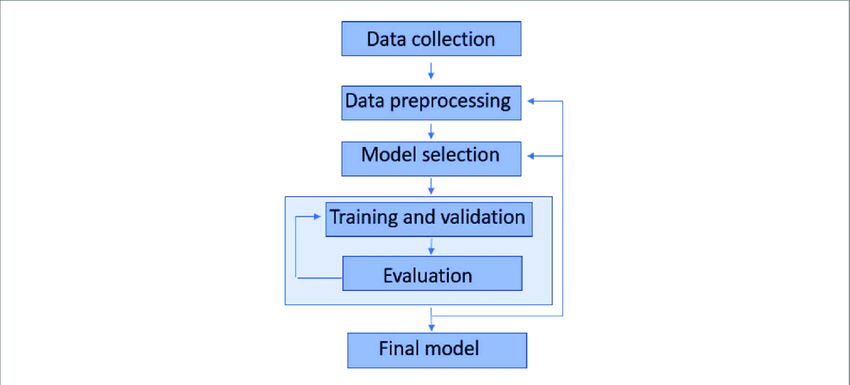

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   importer_id                  10000 non-null  object 
 1   exporter_id                  10000 non-null  object 
 2   hs_code                      10000 non-null  int64  
 3   declared_value               10000 non-null  float64
 4   origin_country               10000 non-null  object 
 5   transport_mode               10000 non-null  object 
 6   route                        10000 non-null  object 
 7   container_count              10000 non-null  int64  
 8   packaging_type               10000 non-null  object 
 9   inspection_history_count     10000 non-null  int64  
 10  previous_overall_risk_score  10000 non-null  float64
 11  country_risk_score           10000 non-null  float64
 12  origin_flag                  10000 non-null  int64  
dtypes: float64(3), in

In [ ]:
from sklearn.model_selection import train_test_split
x=df_encoded.drop("origin_flag",axis=1)
y=df_encoded["origin_flag"]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20)

In [ ]:
# Classification
reg = LazyClassifier(verbose=0, ignore_warnings=False, custom_metric=None)
models, predictions = reg.fit(x_train, x_test, y_train, y_test)
print(models)

In [ ]:
from sklearn.metrics import accuracy_score

class Classification_models:
    def __init__(self, x_train, x_test, y_train, y_test):
        self.x_train = x_train
        self.x_test = x_test
        self.y_train = y_train
        self.y_test = y_test

    def decisiontree(self):
        from sklearn.tree import DecisionTreeClassifier
        model = DecisionTreeClassifier().fit(self.x_train, self.y_train)
        y_train_pred = model.predict(self.x_train)
        y_test_pred = model.predict(self.x_test)
        train_accuracy = accuracy_score(self.y_train, y_train_pred)
        test_accuracy = accuracy_score(self.y_test, y_test_pred)
        return train_accuracy, test_accuracy

    def random_forest_classifier(self):
        from sklearn.ensemble import RandomForestClassifier
        model = RandomForestClassifier().fit(self.x_train, self.y_train)
        y_train_pred = model.predict(self.x_train)
        y_test_pred = model.predict(self.x_test)
        train_accuracy = accuracy_score(self.y_train, y_train_pred)
        test_accuracy = accuracy_score(self.y_test, y_test_pred)
        return train_accuracy, test_accuracy

    def gradient_boosting(self):
        from sklearn.ensemble import GradientBoostingClassifier
        model = GradientBoostingClassifier().fit(self.x_train, self.y_train)
        y_train_pred = model.predict(self.x_train)
        y_test_pred = model.predict(self.x_test)
        train_accuracy = accuracy_score(self.y_train, y_train_pred)
        test_accuracy = accuracy_score(self.y_test, y_test_pred)
        return train_accuracy, test_accuracy

    def adaboost(self):
        from sklearn.ensemble import AdaBoostClassifier
        model = AdaBoostClassifier().fit(self.x_train, self.y_train)
        y_train_pred = model.predict(self.x_train)
        y_test_pred = model.predict(self.x_test)
        train_accuracy = accuracy_score(self.y_train, y_train_pred)
        test_accuracy = accuracy_score(self.y_test, y_test_pred)
        return train_accuracy, test_accuracy

    def extra_trees_classifier(self):
        from sklearn.ensemble import ExtraTreesClassifier
        model = ExtraTreesClassifier().fit(self.x_train, self.y_train)
        y_train_pred = model.predict(self.x_train)
        y_test_pred = model.predict(self.x_test)
        train_accuracy = accuracy_score(self.y_train, y_train_pred)
        test_accuracy = accuracy_score(self.y_test, y_test_pred)
        return train_accuracy, test_accuracy


    def support_vector_machine(self):
        from sklearn.svm import SVC
        model = SVC().fit(self.x_train, self.y_train)
        y_train_pred = model.predict(self.x_train)
        y_test_pred = model.predict(self.x_test)
        train_accuracy = accuracy_score(self.y_train, y_train_pred)
        test_accuracy = accuracy_score(self.y_test, y_test_pred)
        return train_accuracy, test_accuracy

    def logistic_regression(self):
        from sklearn.linear_model import LogisticRegression
        model = LogisticRegression(max_iter=1000).fit(self.x_train, self.y_train)
        y_train_pred = model.predict(self.x_train)
        y_test_pred = model.predict(self.x_test)
        train_accuracy = accuracy_score(self.y_train, y_train_pred)
        test_accuracy = accuracy_score(self.y_test, y_test_pred)
        return train_accuracy, test_accuracy


In [ ]:
model = Classification_models(x_train, x_test, y_train, y_test)

accuracy_scores = {
    'DecisionTree': model.decisiontree(),
    'RandomForest': model.random_forest_classifier(),
    'GradientBoosting': model.gradient_boosting(),
    'AdaBoost': model.adaboost(),
    'ExtraTreesClassifier': model.extra_trees_classifier(),
    'SVM': model.support_vector_machine(),
    'LogisticRegression' : model.logistic_regression()
}

# for classifier, (train_score, test_score) in accuracy_scores.items():
#     print(f"\n{classifier} train accuracy score: {train_score:.4f}")
#     print(f"{classifier} test accuracy score: {test_score:.4f}")

In [ ]:
# Convert to DataFrame for a clean table
accuracy_df = pd.DataFrame(accuracy_scores, index=['Train Accuracy', 'Test Accuracy']).T
accuracy_df = accuracy_df.round(4)  # optional, 4 decimal places

print(accuracy_df)

                      Train Accuracy  Test Accuracy
DecisionTree                  1.0000         0.9955
RandomForest                  1.0000         0.9953
GradientBoosting              0.7551         0.7517
AdaBoost                      0.7461         0.7433
ExtraTreesClassifier          1.0000         0.9961
SVM                           0.7462         0.7434
LogisticRegression            0.7464         0.7436


## Hyperparameter tuning

RandomForest Regressor appears to be the best algorithm based on the provided accuracy scores:

Training Accuracy: 0.99
Test Accuracy: 0.99

This algorithm offers the best balance between high training accuracy and high test accuracy, indicating strong generalization performance and minimal overfitting.

In [ ]:
# 1) Random Forest with tuned parameters

import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# X, y assumed defined already
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

best_rf = RandomForestClassifier(
    n_estimators=300,        # number of trees
    max_depth=20,            # tree depth
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',     # feature selection at each split
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# Train
best_rf.fit(x_train, y_train)

# Predictions
y_train_pred = best_rf.predict(x_train)
y_test_pred = best_rf.predict(x_test)

# Metrics
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred, average="binary")

print("Train Accuracy:", round(train_acc, 4))
print("Test Accuracy:", round(test_acc, 4))
print("F1 Score:", round(f1, 4))
#print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
# Get confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Create a DataFrame for better visualization
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

print("\nConfusion Matrix:\n")
print(cm_df)
print("")

print("Classification Report:\n", classification_report(y_test, y_test_pred))

# Save best model
joblib.dump(best_rf, "best_random_forest.joblib")
print("Random Forest model trained, evaluated, and saved successfully 🚀")

Train Accuracy: 0.9973
Test Accuracy: 0.9843
F1 Score: 0.9683

Confusion Matrix:

          Predicted 0  Predicted 1
Actual 0        11861            0
Actual 1          249         3798

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99     11861
           1       1.00      0.94      0.97      4047

    accuracy                           0.98     15908
   macro avg       0.99      0.97      0.98     15908
weighted avg       0.98      0.98      0.98     15908

Random Forest model trained, evaluated, and saved successfully 🚀


In [ ]:
df.head(12)

,importer_id,exporter_id,hs_code,declared_value,origin_country,transport_mode,route,container_count,packaging_type,inspection_history_count,previous_overall_risk_score,country_risk_score,origin_flag
0,IMP357,EXP199,29211920,46561.43,DE,road,DEAE,5,box,3,0.34,0.06,0
1,IMP134,EXP459,85171200,23743.07,CN,road,SGAE,2,loose,0,0.51,0.57,0
2,IMP446,EXP340,71131990,44993.75,SG,road,INAE,4,box,5,0.27,0.65,0
3,IMP093,EXP092,10061001,33719.88,SG,sea,USAE,3,bag,3,0.44,0.90,0
4,IMP399,EXP338,93049099,39873.53,CN,sea,INAE,4,loose,5,0.53,0.42,0
5,IMP268,EXP483,85171200,18758.10,AE,air,DEAE,3,loose,0,0.82,0.61,0
6,IMP394,EXP198,30049070,20912.75,IN,road,INAE,1,loose,2,0.29,0.00,0
7,IMP182,EXP332,2013010,22151.23,IN,air,DEAE,3,drum,1,0.43,0.82,1
8,IMP091,EXP282,71131990,2772.09,CN,sea,USAE,4,loose,1,0.23,0.68,1
9,IMP066,EXP190,71131990,6117.28,DE,road,AEAE,1,loose,2,0.81,0.77,0


## Evaluation

In [ ]:
# Evaluate Saved Random Forest Model

import joblib
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Load the saved model
loaded_rf = joblib.load("best_random_forest.joblib")

# Predict on test data
y_test_pred_loaded = loaded_rf.predict(x_test)

# Metrics
test_acc_loaded = accuracy_score(y_test, y_test_pred_loaded)
f1_loaded = f1_score(y_test, y_test_pred_loaded, average="weighted")

print("Loaded Model Evaluation")
print("Test Accuracy:", round(test_acc_loaded, 4))
print("F1 Score:", round(f1_loaded, 4))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred_loaded))

# Confusion Matrix as Table
cm_loaded = confusion_matrix(y_test, y_test_pred_loaded)
cm_df_loaded = pd.DataFrame(
    cm_loaded,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

print("\nConfusion Matrix (as Table):\n")
print(cm_df_loaded)


Loaded Model Evaluation
Test Accuracy: 0.9843
F1 Score: 0.9842

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99     11861
           1       1.00      0.94      0.97      4047

    accuracy                           0.98     15908
   macro avg       0.99      0.97      0.98     15908
weighted avg       0.98      0.98      0.98     15908


Confusion Matrix (as Table):

          Predicted 0  Predicted 1
Actual 0        11861            0
Actual 1          249         3798


Loaded Model Evaluation
Test Accuracy: 0.9843
F1 Score: 0.9842

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99     11861
           1       1.00      0.94      0.97      4047

    accuracy                           0.98     15908
   macro avg       0.99      0.97      0.98     15908
weighted avg       0.98      0.98      0.98     15908


Confusion Matrix (as Table):

          Predicted 0  Predicted 1
Actual 0        11861            0
Actual 1          249         3798


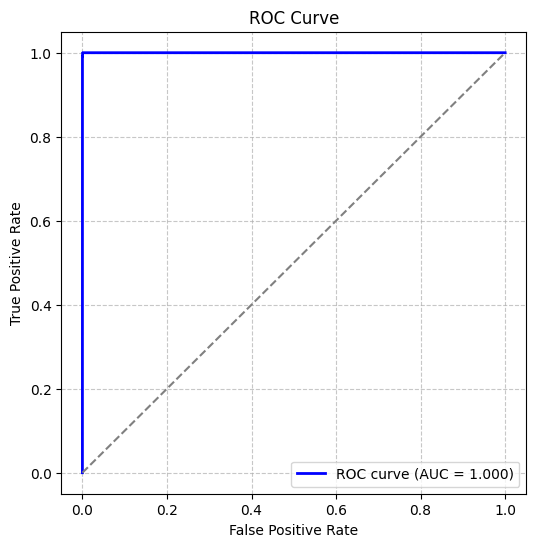

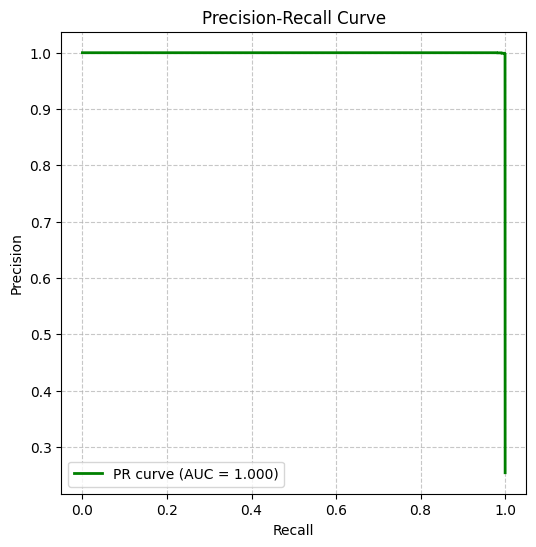

In [ ]:

# 3) ROC & AUC Evaluation for Saved Random Forest Model

import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve, auc
)

# Load the saved model
loaded_rf = joblib.load("best_random_forest.joblib")

# Predict probabilities (needed for ROC/AUC)
y_test_probs = loaded_rf.predict_proba(x_test)[:, 1]  # probability for class 1
y_test_pred = loaded_rf.predict(x_test)

# Basic Metrics
print("Loaded Model Evaluation")
print("Test Accuracy:", round(accuracy_score(y_test, y_test_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_test_pred, average="weighted"), 4))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

# Confusion Matrix as Table
cm = confusion_matrix(y_test, y_test_pred)
cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"])
print("\nConfusion Matrix (as Table):\n")
print(cm_df)

# ROC Curve & AUC
fpr, tpr, thresholds = roc_curve(y_test, y_test_probs)
roc_auc = roc_auc_score(y_test, y_test_probs)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

# Precision-Recall Curve
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_test_probs)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 6))
plt.plot(recall, precision, color="green", lw=2, label=f"PR curve (AUC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()


# Testing

In [ ]:
pd.set_option("display.max_columns", None)
df_encoded.head(2)

,importer_id,exporter_id,previous_overall_risk_score,country_risk_score,origin_country_AE,origin_country_CN,origin_country_DE,origin_country_IN,origin_country_SG,origin_country_US,transport_mode_air,transport_mode_road,transport_mode_sea,route_AEAE,route_CNAE,route_DEAE,route_INAE,route_SGAE,route_USAE,container_count_1,container_count_2,container_count_3,container_count_4,container_count_5,hs_code_1012100,hs_code_2013010,hs_code_10061001,hs_code_10061002,hs_code_29211920,hs_code_30049070,hs_code_71131990,hs_code_85171200,hs_code_93049099,packaging_type_bag,packaging_type_box,packaging_type_drum,packaging_type_loose,inspection_history_count_0,inspection_history_count_1,inspection_history_count_2,inspection_history_count_3,inspection_history_count_4,inspection_history_count_5,declared_value,origin_flag
0,190.0,120.0,1116.0,961.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.688196,0
1,262.0,95.0,864.0,783.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.520605,0


In [ ]:
pd.set_option("display.max_columns", None)

df_encoded[df_encoded['origin_flag'] == 1].head(2)

,importer_id,exporter_id,previous_overall_risk_score,country_risk_score,origin_country_AE,origin_country_CN,origin_country_DE,origin_country_IN,origin_country_SG,origin_country_US,transport_mode_air,transport_mode_road,transport_mode_sea,route_AEAE,route_CNAE,route_DEAE,route_INAE,route_SGAE,route_USAE,container_count_1,container_count_2,container_count_3,container_count_4,container_count_5,hs_code_1012100,hs_code_2013010,hs_code_10061001,hs_code_10061002,hs_code_29211920,hs_code_30049070,hs_code_71131990,hs_code_85171200,hs_code_93049099,packaging_type_bag,packaging_type_box,packaging_type_drum,packaging_type_loose,inspection_history_count_0,inspection_history_count_1,inspection_history_count_2,inspection_history_count_3,inspection_history_count_4,inspection_history_count_5,declared_value,origin_flag
59304,148.0,144.0,976.0,772.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.823751,1
59305,93.0,133.0,797.0,728.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-0.145530,1


In [ ]:
import numpy as np

# Your input data row
input_data = [
    148.00, 144.00, 976.00, 772.00, 0.00, 1.00, 0.00, 0.00, 0.00, 0.00,
    1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.00, 0.00, 0.00,
    0.00, 1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.00, 0.00, 0.00,
    0.00, 0.00, 0.00, 0.00, 0.00, 1.00, 0.00, 0.00, 0.00, 0.00,
    0.00, 1.00, 0.00, 0.82
]

# Convert to numpy array with correct shape
input_array = np.array(input_data).reshape(1, -1)

# Make prediction
y_pred = loaded_rf.predict(input_array)

print("Predicted class:", y_pred[0])

Predicted class: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but RandomForestClassifier was fitted with feature names



In [ ]:
import numpy as np

# New input row
input_data = [
    190.00, 120.00, 1116.00, 961.00, 0.00, 1.00, 0.00, 0.00, 0.00, 0.00,
    1.00, 0.00, 0.00, 0.00, 0.00, 1.00, 0.00, 0.00, 0.00, 0.00,
    0.00, 0.00, 0.00, 1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.00,
    0.00, 0.00, 0.00, 0.00, 0.00, 1.00, 0.00, 0.00, 0.00, 1.00,
    0.00, 0.00, 0.00, 0.69
]

# Reshape into 2D array
input_array = np.array(input_data).reshape(1, -1)

# Prediction
y_pred = loaded_rf.predict(input_array)
y_prob = loaded_rf.predict_proba(input_array)

print("Predicted class:", y_pred[0])
print("Probability of Class 0:", y_prob[0][0])
print("Probability of Class 1:", y_prob[0][1])

Predicted class: 0
Probability of Class 0: 0.9668746572216812
Probability of Class 1: 0.033125342778318856


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but RandomForestClassifier was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but RandomForestClassifier was fitted with feature names



## Decoding & Model  

In [ ]:
df.head(2)

,importer_id,exporter_id,hs_code,declared_value,origin_country,transport_mode,route,container_count,packaging_type,inspection_history_count,previous_overall_risk_score,country_risk_score,origin_flag
0,IMP357,EXP199,29211920,46561.43,DE,road,DEAE,5,box,3,0.34,0.06,0
1,IMP134,EXP459,85171200,23743.07,CN,road,SGAE,2,loose,0,0.51,0.57,0


In [ ]:
import pandas as pd
import joblib

# -------------------------------
# Load saved pipeline and model
# -------------------------------
pipeline = joblib.load("/content/drive/MyDrive/ML3/preprocessor_pipeline.pkl")
loaded_rf = joblib.load("/content/drive/MyDrive/ML3/best_random_forest.joblib")

# -------------------------------
# Select one row from df (drop target column)
# -------------------------------
df_raw = df.drop(columns=["origin_flag"]).iloc[[0]]   # pick first row, change index as needed

# -------------------------------
# Encode input row using pipeline
# -------------------------------
X_encoded = pipeline.transform(df_raw)

# -------------------------------
# Predict with Random Forest
# -------------------------------
y_pred = loaded_rf.predict(X_encoded)
y_proba = loaded_rf.predict_proba(X_encoded)  # probability scores

# -------------------------------
# Decode + Display prediction
# -------------------------------
label_map = {0: "Non-Risky", 1: "Risky"}
print("✅ Prediction:", label_map[y_pred[0]])
print("📊 Probabilities:", y_proba[0])

✅ Prediction: Non-Risky
📊 Probabilities: [0.92044757 0.07955243]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but RandomForestClassifier was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but RandomForestClassifier was fitted with feature names



In [ ]:
df.head(2)

,importer_id,exporter_id,hs_code,declared_value,origin_country,transport_mode,route,container_count,packaging_type,inspection_history_count,previous_overall_risk_score,country_risk_score,origin_flag
0,IMP357,EXP199,29211920,46561.43,DE,road,DEAE,5,box,3,0.34,0.06,0
1,IMP134,EXP459,85171200,23743.07,CN,road,SGAE,2,loose,0,0.51,0.57,0


# Streamlit part

In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 63.4 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
from sklearn.base import BaseEstimator, TransformerMixin


# Define FrequencyEncoder (for pipeline unpickling)
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.freq_map = {}

    def fit(self, X, y=None):
        for col in X.columns:
            freq = X[col].value_counts()
            self.freq_map[col] = freq.to_dict()
        return self

    def transform(self, X):
        X_encoded = X.copy()
        for col in X.columns:
            X_encoded[col] = X[col].map(self.freq_map[col]).fillna(0)
        return X_encoded


# Load saved pipeline and model
pipeline = joblib.load("/content/drive/MyDrive/ML3/preprocessor_pipeline.pkl")
loaded_rf = joblib.load("/content/drive/MyDrive/ML3/best_random_forest.joblib")

st.title("🚢 Country of origin - Risk Engine prediction")

st.write("### Enter shipment details below:")


# Predefined values (from dataset)
importer_ids = ['IMP357','IMP134','IMP446','IMP093','IMP399','IMP268','IMP394','IMP182','IMP091','IMP066','IMP497','IMP248','IMP151','IMP343','IMP203','IMP236','IMP259','IMP356','IMP114','IMP074','IMP160','IMP138','IMP202','IMP027','IMP081','IMP198','IMP329','IMP368','IMP041','IMP316','IMP421','IMP092','IMP023','IMP291','IMP327','IMP230','IMP332','IMP300','IMP088','IMP470','IMP190','IMP188','IMP242','IMP122','IMP349','IMP181','IMP398','IMP452','IMP261','IMP238','IMP039','IMP350','IMP469','IMP054','IMP436','IMP244','IMP418','IMP191','IMP306','IMP260','IMP481','IMP173','IMP438','IMP379','IMP472','IMP068','IMP030','IMP196','IMP407','IMP480','IMP077','IMP206','IMP305','IMP229','IMP002','IMP176','IMP393','IMP437','IMP442','IMP008','IMP296','IMP140','IMP078','IMP361','IMP253','IMP085','IMP353','IMP408','IMP493','IMP089','IMP416','IMP212','IMP424','IMP218','IMP288','IMP222','IMP309','IMP170','IMP017','IMP280','IMP378','IMP317','IMP430','IMP330','IMP477','IMP155','IMP072','IMP389','IMP380','IMP101','IMP045','IMP076','IMP371','IMP410','IMP250','IMP184','IMP121','IMP369','IMP337','IMP172','IMP227','IMP318','IMP279','IMP159','IMP443','IMP223','IMP014','IMP156','IMP139','IMP273','IMP374','IMP020','IMP445','IMP471','IMP053','IMP396','IMP475','IMP479','IMP090','IMP498','IMP079','IMP331','IMP153','IMP252','IMP494','IMP451','IMP373','IMP108','IMP154','IMP105','IMP245','IMP409','IMP038','IMP298','IMP293','IMP287','IMP432','IMP214','IMP048','IMP335','IMP405','IMP400','IMP147','IMP144','IMP210','IMP235','IMP112','IMP022','IMP220','IMP062','IMP303','IMP146','IMP186','IMP067','IMP086','IMP486','IMP246','IMP137','IMP461','IMP049','IMP037','IMP455','IMP363','IMP468','IMP299','IMP449','IMP152','IMP141','IMP024','IMP117','IMP011','IMP495','IMP201','IMP164','IMP297','IMP401','IMP422','IMP204','IMP107','IMP467','IMP278','IMP115','IMP082','IMP026','IMP073','IMP320','IMP183','IMP482','IMP419','IMP240','IMP367','IMP217','IMP080','IMP180','IMP012','IMP162','IMP021','IMP423','IMP488','IMP148','IMP255','IMP347','IMP360','IMP415','IMP351','IMP127','IMP440','IMP459','IMP010','IMP427','IMP311','IMP456','IMP219','IMP395','IMP465','IMP265','IMP336','IMP257','IMP025','IMP046','IMP402','IMP018','IMP095','IMP447','IMP341','IMP428','IMP136','IMP448','IMP478','IMP388','IMP124','IMP199','IMP286','IMP342','IMP099','IMP487','IMP035','IMP266','IMP130','IMP372','IMP344','IMP312','IMP346','IMP322','IMP441','IMP483','IMP033','IMP390','IMP213','IMP251','IMP391','IMP135','IMP061','IMP104','IMP433','IMP047','IMP200','IMP006','IMP166','IMP476','IMP001','IMP358','IMP149','IMP453','IMP031','IMP382','IMP009','IMP157','IMP304','IMP102','IMP100','IMP243','IMP096','IMP110','IMP094','IMP119','IMP307','IMP234','IMP225','IMP207','IMP310','IMP116','IMP328','IMP055','IMP070','IMP375','IMP431','IMP133','IMP208','IMP308','IMP301','IMP384','IMP282','IMP237','IMP165','IMP163','IMP126','IMP118','IMP274','IMP013','IMP106','IMP484','IMP256','IMP125','IMP439','IMP263','IMP226','IMP032','IMP058','IMP019','IMP345','IMP315','IMP294','IMP111','IMP064','IMP283','IMP178','IMP069','IMP179','IMP474','IMP302','IMP454','IMP232','IMP051','IMP269','IMP496','IMP321','IMP040','IMP003','IMP420','IMP050','IMP281','IMP241','IMP377','IMP123','IMP355','IMP387','IMP197','IMP097','IMP434','IMP270','IMP209','IMP161','IMP413','IMP370','IMP109','IMP485','IMP132','IMP228','IMP473','IMP326','IMP462','IMP194','IMP258','IMP187','IMP224','IMP348','IMP285','IMP290','IMP295','IMP264','IMP366','IMP004','IMP383','IMP249','IMP042','IMP015','IMP150','IMP429','IMP044','IMP325','IMP120','IMP450','IMP193','IMP056','IMP289','IMP060','IMP414','IMP083','IMP457','IMP313','IMP158','IMP406','IMP016','IMP435','IMP071','IMP247','IMP364','IMP403','IMP205','IMP466','IMP084','IMP216','IMP145','IMP057','IMP233','IMP490','IMP324','IMP397','IMP411','IMP063','IMP028','IMP174','IMP492','IMP029','IMP052','IMP499','IMP215','IMP319','IMP167','IMP338','IMP333','IMP168','IMP275','IMP034','IMP444','IMP129','IMP340','IMP113','IMP007','IMP075','IMP239','IMP087','IMP314','IMP339','IMP271','IMP386','IMP404','IMP491','IMP267','IMP365','IMP425','IMP221','IMP103','IMP262','IMP276','IMP392','IMP352','IMP292','IMP412','IMP231','IMP385','IMP185','IMP171','IMP005','IMP036','IMP098','IMP464','IMP177','IMP323','IMP211','IMP426','IMP381','IMP362','IMP192','IMP359','IMP131','IMP043','IMP277','IMP195','IMP463','IMP254','IMP417','IMP059','IMP284','IMP354','IMP189','IMP272','IMP460','IMP500','IMP169','IMP376','IMP128','IMP458','IMP489','IMP334','IMP065','IMP175','IMP142','IMP143']
exporter_ids = ['EXP199','EXP459','EXP340','EXP092','EXP338','EXP483','EXP198','EXP332','EXP282','EXP190','EXP217','EXP153','EXP059','EXP128','EXP426','EXP316','EXP244','EXP420','EXP251','EXP348','EXP497','EXP312','EXP240','EXP215','EXP418','EXP202','EXP322','EXP473','EXP254','EXP451','EXP227','EXP156','EXP328','EXP433','EXP331','EXP131','EXP296','EXP018','EXP396','EXP136','EXP025','EXP249','EXP141','EXP466','EXP453','EXP170','EXP293','EXP263','EXP339','EXP184','EXP319','EXP355','EXP301','EXP115','EXP268','EXP101','EXP203','EXP474','EXP050','EXP439','EXP120','EXP314','EXP407','EXP068','EXP219','EXP045','EXP344','EXP090','EXP105','EXP373','EXP472','EXP480','EXP082','EXP399','EXP166','EXP270','EXP027','EXP374','EXP430','EXP086','EXP069','EXP414','EXP181','EXP119','EXP487','EXP450','EXP428','EXP225','EXP164','EXP438','EXP498','EXP478','EXP494','EXP257','EXP424','EXP204','EXP360','EXP388','EXP334','EXP464','EXP335','EXP458','EXP189','EXP462','EXP132','EXP255','EXP403','EXP008','EXP169','EXP470','EXP269','EXP055','EXP262','EXP461','EXP337','EXP150','EXP346','EXP242','EXP006','EXP044','EXP159','EXP489','EXP210','EXP124','EXP238','EXP404','EXP325','EXP167','EXP042','EXP484','EXP362','EXP452','EXP111','EXP467','EXP178','EXP051','EXP434','EXP010','EXP486','EXP354','EXP284','EXP187','EXP387','EXP250','EXP143','EXP298','EXP108','EXP122','EXP468','EXP379','EXP109','EXP011','EXP076','EXP081','EXP306','EXP308','EXP375','EXP264','EXP012','EXP098','EXP440','EXP259','EXP214','EXP329','EXP058','EXP072','EXP229','EXP038','EXP102','EXP443','EXP064','EXP386','EXP077','EXP168','EXP343','EXP089','EXP490','EXP103','EXP216','EXP087','EXP411','EXP085','EXP014','EXP447','EXP378','EXP192','EXP266','EXP151','EXP363','EXP209','EXP320','EXP481','EXP243','EXP445','EXP275','EXP002','EXP463','EXP020','EXP207','EXP350','EXP402','EXP429','EXP359','EXP333','EXP253','EXP419','EXP230','EXP144','EXP117','EXP288','EXP265','EXP053','EXP431','EXP094','EXP246','EXP046','EXP091','EXP016','EXP256','EXP057','EXP056','EXP047','EXP372','EXP174','EXP371','EXP183','EXP309','EXP163','EXP211','EXP024','EXP303','EXP107','EXP278','EXP479','EXP326','EXP304','EXP417','EXP054','EXP237','EXP017','EXP218','EXP384','EXP286','EXP422','EXP252','EXP280','EXP297','EXP097','EXP157','EXP281','EXP323','EXP032','EXP241','EXP029','EXP392','EXP287','EXP361','EXP080','EXP313','EXP381','EXP423','EXP208','EXP043','EXP073','EXP113','EXP213','EXP233','EXP482','EXP154','EXP267','EXP095','EXP152','EXP040','EXP234','EXP096','EXP496','EXP383','EXP147','EXP400','EXP327','EXP061','EXP078','EXP492','EXP023','EXP212','EXP104','EXP228','EXP195','EXP291','EXP500','EXP276','EXP003','EXP364','EXP390','EXP155','EXP175','EXP048','EXP247','EXP121','EXP366','EXP488','EXP172','EXP357','EXP205','EXP324','EXP129','EXP180','EXP285','EXP200','EXP302','EXP436','EXP292','EXP084','EXP022','EXP465','EXP397','EXP004','EXP294','EXP353','EXP469','EXP015','EXP062','EXP123','EXP307','EXP367','EXP201','EXP079','EXP041','EXP446','EXP283','EXP457','EXP493','EXP031','EXP425','EXP456','EXP013','EXP112','EXP110','EXP093','EXP365','EXP444','EXP475','EXP021','EXP019','EXP368','EXP232','EXP194','EXP114','EXP116','EXP321','EXP471','EXP389','EXP258','EXP342','EXP273','EXP347','EXP037','EXP033','EXP311','EXP197','EXP395','EXP300','EXP318','EXP295','EXP133','EXP377','EXP380','EXP127','EXP030','EXP148','EXP315','EXP130','EXP271','EXP158','EXP083','EXP261','EXP182','EXP405','EXP173','EXP441','EXP289','EXP358','EXP351','EXP477','EXP317','EXP432','EXP349','EXP065','EXP220','EXP454','EXP279','EXP260','EXP369','EXP356','EXP382','EXP476','EXP352','EXP393','EXP236','EXP206','EXP149','EXP036','EXP049','EXP224','EXP223','EXP437','EXP001','EXP099','EXP408','EXP185','EXP035','EXP385','EXP193','EXP026','EXP345','EXP231','EXP491','EXP341','EXP394','EXP070','EXP499','EXP410','EXP406','EXP435','EXP248','EXP066','EXP106','EXP160','EXP191','EXP226','EXP060','EXP427','EXP409','EXP239','EXP495','EXP134','EXP171','EXP142','EXP179','EXP442','EXP485','EXP165','EXP074','EXP277','EXP290','EXP196','EXP460','EXP336','EXP140','EXP235','EXP161','EXP100','EXP034','EXP138','EXP177','EXP370','EXP125','EXP221','EXP310','EXP075','EXP063','EXP067','EXP188','EXP448','EXP391','EXP222','EXP449','EXP118','EXP186','EXP145','EXP126','EXP398','EXP245','EXP330','EXP005','EXP146','EXP135','EXP413','EXP421','EXP028','EXP274','EXP009','EXP416','EXP139','EXP272','EXP412','EXP176','EXP088','EXP455','EXP137','EXP162','EXP071','EXP376','EXP305','EXP401','EXP052','EXP039','EXP007','EXP299','EXP415']
hs_codes = [29211920,85171200,71131990,10061001,93049099,30049070,2013010,1012100,10061002]
origin_countries = ['DE','CN','SG','AE','IN','US']
transport_modes = ['road','sea','air']
routes = ['DEAE','SGAE','INAE','USAE','AEAE','CNAE']
container_counts = [5,2,4,3,1]
packaging_types = ['box','loose','bag','drum']
inspection_counts = [3,0,5,2,1,4]

# (risk scores could also be dropdowns, but better keep them as numeric inputs)

# Two-column layout
col1, col2 = st.columns(2)

with col1:
    importer_id = st.selectbox("Importer ID", importer_ids)
    exporter_id = st.selectbox("Exporter ID", exporter_ids)
    hs_code = st.selectbox("HS Code", hs_codes)
    declared_value = st.number_input("Declared Value", value=46561.43)
    origin_country = st.selectbox("Origin Country", origin_countries)
    transport_mode = st.selectbox("Transport Mode", transport_modes)

with col2:
    route = st.selectbox("Route", routes)
    container_count = st.selectbox("Container Count", container_counts)
    packaging_type = st.selectbox("Packaging Type", packaging_types)
    inspection_history_count = st.selectbox("Inspection History Count", inspection_counts)
    previous_overall_risk_score = st.number_input("Previous Overall Risk Score", value=0.34)
    country_risk_score = st.number_input("Country Risk Score", value=0.06)


# Convert to DataFrame
df_raw = pd.DataFrame([{
    "importer_id": importer_id,
    "exporter_id": exporter_id,
    "hs_code": hs_code,
    "declared_value": declared_value,
    "origin_country": origin_country,
    "transport_mode": transport_mode,
    "route": route,
    "container_count": container_count,
    "packaging_type": packaging_type,
    "inspection_history_count": inspection_history_count,
    "previous_overall_risk_score": previous_overall_risk_score,
    "country_risk_score": country_risk_score,
}])

st.write("### 🔎 Input Data")
st.dataframe(df_raw)

# Predict Button
if st.button("🔮 Predict"):
    X_encoded = pipeline.transform(df_raw)
    y_pred = loaded_rf.predict(X_encoded)
    y_proba = loaded_rf.predict_proba(X_encoded)

    label_map = {0: "Non-Risky", 1: "Risky"}
    prediction = label_map[y_pred[0]]
    probabilities = dict(zip(label_map.values(), y_proba[0]))

    st.subheader("✅ Prediction Result")
    st.success(f"Prediction: **{prediction}**")

    st.subheader("📊 Probabilities")
    st.json(probabilities)


Writing app.py


In [ ]:
!ngrok config add-authtoken 34rym51lPBarWBiLEqQaJFwJC6Y_Q4MhJeo2286pvmCEE2co

/bin/bash: line 1: ngrok: command not found


In [ ]:
pip install pyngrok

In [ ]:
from pyngrok import ngrok
!streamlit run app.py &>/dev/null&
url = ngrok.connect(8501)
print("🌐 App running at:", url)

🌐 App running at: NgrokTunnel: "https://alina-uninstalled-aleida.ngrok-free.dev" -> "http://localhost:8501"


## Description (In progress)

In [ ]:
# --- Install dependencies ---
!pip install shap lime joblib

In [ ]:

# --- Imports ---
import joblib
import shap
import pandas as pd
import numpy as np

# --- Load model ---
model_path = "/content/drive/MyDrive/ML3/best_random_forest.joblib"
rf_model = joblib.load(model_path)

# --- SHAP Explainer ---
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(x)

# --- Example: Explain first prediction ---
i = 0
sample = x.iloc[i:i+1]

prediction = rf_model.predict(sample)[0]
prediction_proba = rf_model.predict_proba(sample)[0][1]

# Get SHAP values for this sample
shap_contribs = shap_values[1][i]  # class=1 (Risky)
feature_importance = dict(zip(x.columns, shap_contribs))

# --- Convert to business-friendly explanation ---
def generate_explanation(features, contribs, prediction, proba):
    sorted_features = sorted(contribs.items(), key=lambda s: abs(s[1]), reverse=True)
    reasons = []

    for feat, val in sorted_features[:3]:  # top 3 contributing features
        if val > 0:
            reasons.append(f"{feat} increased risk")
        else:
            reasons.append(f"{feat} reduced risk")

    # Base explanation
    if prediction == 1:
        decision = f"Prediction: 🚨 Risky (probability={proba:.2f})."
        explanation = "Reason: " + ", ".join(reasons)
    else:
        decision = f"Prediction: ✅ Non-Risky (probability={proba:.2f})."
        explanation = "Reason: " + ", ".join(reasons)

    return decision + " " + explanation

# Generate explanation for the sample
print(generate_explanation(sample, feature_importance, prediction, prediction_proba))

# --- Optional: Add simple rule-based reasoning ---
def add_domain_rules(row):
    rules = []
    if "container_count" in row and row["container_count"].values[0] > 50:
        rules.append("Large shipment size increases risk.")
    if "declared_value" in row and row["declared_value"].values[0] < 1000:
        rules.append("Low declared value may indicate under-invoicing.")
    if "origin_country" in row and row["origin_country"].values[0] in ["HighRiskCountryA", "HighRiskCountryB"]:
        rules.append("Origin country flagged as high risk.")

    return rules

extra_rules = add_domain_rules(sample)
print("Additional Business Rules:", extra_rules)

In [ ]:
ggimport shap
import joblib
import pandas as pd

# Load encoded dataset
df_encoded = pd.read_csv("/content/encoded_dataset.csv")

# Separate features and target
X = df_encoded.drop("origin_flag", axis=1)
y = df_encoded["origin_flag"]

# Load trained model
best_rf = joblib.load("/content/drive/MyDrive/ML3/best_random_forest.joblib")

# SHAP explainer
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X)

# Summary plot (all features)
shap.summary_plot(shap_values[1], X, feature_names=X.columns)

# Force plot for single prediction
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[1][0,:], feature_names=X.columns)

In [ ]:
import shap
import joblib
import pandas as pd
# Define FrequencyEncoder again
from sklearn.base import BaseEstimator, TransformerMixin

class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.freq_map = {}

    def fit(self, X, y=None):
        for col in X.columns:
            freq = X[col].value_counts()
            self.freq_map[col] = freq.to_dict()
        return self

    def transform(self, X):
        X_encoded = X.copy()
        for col in X.columns:
            X_encoded[col] = X[col].map(self.freq_map[col]).fillna(0)
        return X_encoded


# Load pipeline and model
pipeline = joblib.load("/content/drive/MyDrive/ML3/preprocessor_pipeline.pkl")
best_rf = joblib.load("/content/drive/MyDrive/ML3/best_random_forest.joblib")

# Load encoded dataset
df_encoded = pd.read_csv("/content/encoded_dataset.csv")

# Separate features and target
X = df_encoded.drop("origin_flag", axis=1)
y = df_encoded["origin_flag"]

# Get feature names
ohe = pipeline.named_steps["preprocessor"].named_transformers_["onehot"]
ohe_features = ohe.get_feature_names_out(["origin_country", "transport_mode", "route",
                                          "container_count","hs_code","packaging_type","inspection_history_count"])
all_features = ["importer_id", "exporter_id", "previous_overall_risk_score", "country_risk_score"] + list(ohe_features) + ["declared_value"]

# SHAP explainer
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_encoded)

# Summary plot (all features)
shap.summary_plot(shap_values[1], X_encoded, feature_names=all_features)

# Force plot for single prediction
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[1][0,:], feature_names=all_features)
